In [97]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
import operator

In [98]:
load_dotenv()

True

In [99]:
model=ChatGoogleGenerativeAI(model='gemini-3.5-flash')

In [100]:
class EvaluationSchema(BaseModel):
    feedback: str= Field(description='Detailed feedbackfor the essay')
    score: int =Field(description='Score out of 10',ge=0, le=10)

In [101]:
structured_model=model.with_structured_output(EvaluationSchema)

In [102]:
essay= """The Role of India in AI Revolution

Artificial Intelligence or AI as everyone calls it nowadays is changing everything fast. From phones to big industries every country is trying to be top in AI. India is also playing a very big role in this whole AI thing, maybe even bigger than what people think. Its not just using American apps anymore, India is actually building a lot of cool stuff and pushing the tech forward in its own way.

First of all India has so many people and most of them are young engineers and tech lovers. GitHub says Indian developers are everywhere and contributing to many open source AI projects. Big companies like Google, Microsoft and IBM have huge R&D centers in India like in Bangalore or Hyderabad because Indian engineers are smart and cheap compared to US workers. Though to be honest a lot of college engineering passouts still need to learn actual deep learning and proper coding to make really advanced AI models.

Another main thing is how Indian government created things like UPI and Aadhaar which everyone uses daily. Because millions of people do online transactions everyday, it creates massive amount of data. AI needs data to learn right? So India has one of the biggest dataset pool in the world. And the government is also making the "IndiaAI Mission" to buy GPUs and help startups, though getting good GPU chips is still very hard and costly for small Indian startups right now.

Unlike Western countries where AI is mostly for making fancy chatbots or making profits, in India AI is used for real everyday problems. Like in agriculture farmers are using AI apps on their mobile to check crop disease from a photo. Or in hospitals where there is less doctors, AI helps in reading X-rays faster. Also India has so many languages like Hindi, Tamil, Bengali, Kannada etc. So NLP AI tools like Bhashini are very crucial so that poor people in villages who don't know English can talk to government services in their local language.

Of course there are many problems also India is facing in AI. The main problem is hardware. We dont manufacture high end chips like NVIDIA or TSMC here so we have to import everything from outside which is super expensive. Also privacy issue is there, people don't know where their data is going. And many people fear AI will take away IT jobs which is a big part of Indian economy.

To conclude, India's role in AI is going to be massive in coming years. It might not have the biggest AI models like ChatGPT right now, but it has the talent, the data and the necessity to solve big problems using tech. If India solves its hardware and training issues, it can easily become a global leader in AI for developing world."""

In [103]:
prompt=f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {essay}'

In [104]:
structured_model.invoke(prompt).feedback

"The essay is well-structured and presents a compelling, highly relevant narrative about India's unique position in the global AI landscape, supported by excellent real-world examples (like UPI, Bhashini, and crop diagnosis apps). However, from a language quality perspective, there are several areas that need improvement to make the writing more academic and professional. First, the tone is quite informal and conversational; phrases like 'this whole AI thing', 'cool stuff', 'smart and cheap' (use 'cost-effective' instead), and rhetorical questions like 'AI needs data to learn right?' should be replaced with formal alternatives. Second, there are minor grammatical and punctuation errors, such as missing apostrophes in contractions ('Its' instead of 'It's', 'dont' instead of 'don't') and subject-verb/noun agreement errors ('less doctors' should be 'fewer doctors'). Lastly, regional colloquialisms such as 'engineering passouts' should be replaced with standard terms like 'engineering grad

In [105]:
class UPSCState(TypedDict):

    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int],operator.add]
    avg_score: float

In [106]:
def evaluate_language(state: UPSCState):

    prompt=f'Evaluate the language quality of the following essay and provide a feedback and assign a score out of 10\n {state["essay"]}'
    output=structured_model.invoke(prompt)

    return{'language_feedback':output.feedback, 'individual_scores':[output.score]}


In [107]:
def evaluate_analysis(state: UPSCState):

    prompt=f'Evaluate the depth of anaysis of the following essay and provide a feedback and assign a score out of 10\n {state["essay"]}'
    output=structured_model.invoke(prompt)

    return{'analysis_feedback':output.feedback, 'individual_scores':[output.score]}


In [108]:
def evaluate_thought(state: UPSCState):

    prompt=f'Evaluate the clarity of thought of the following essay and provide a feedback and assign a score out of 10\n {state["essay"]}'
    output=structured_model.invoke(prompt)

    return{'clarity_feedback':output.feedback, 'individual_scores':[output.score]}


In [109]:
def final_evaluation(state: UPSCState):

    #summary feedback
    prompt=f'Based on the following feedbacks create a summarized feedback \n langauage feedback -{state["language_feedback"]} \n depth of analysis feedback- {state["analysis_feedback"]} \n Clarity of thought feedback - {state["clarity_feedback"]}'
    overall_feedback= model.invoke(prompt).content

    #avg calculate
    avg_score=sum(state["individual_scores"])/len(state["individual_scores"])

    return {'overall_feedback':overall_feedback, 'avg_score':avg_score}

In [110]:
graph= StateGraph(UPSCState)

graph.add_node('evaluate_language',evaluate_language)
graph.add_node('evaluate_analysis',evaluate_analysis)
graph.add_node('evaluate_thought',evaluate_thought)
graph.add_node('final_evaluation',final_evaluation)

In [111]:
#edges
graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')

graph.add_edge('evaluate_language','final_evaluation')
graph.add_edge('evaluate_analysis','final_evaluation')
graph.add_edge('evaluate_thought','final_evaluation')

graph.add_edge('final_evaluation',END)

workflow= graph.compile()

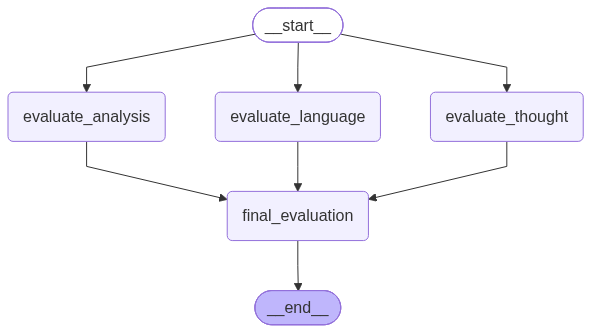

In [112]:
workflow

In [113]:
initialState={
    'essay':essay
}

workflow.invoke(initialState)

{'essay': 'The Role of India in AI Revolution\n\nArtificial Intelligence or AI as everyone calls it nowadays is changing everything fast. From phones to big industries every country is trying to be top in AI. India is also playing a very big role in this whole AI thing, maybe even bigger than what people think. Its not just using American apps anymore, India is actually building a lot of cool stuff and pushing the tech forward in its own way.\n\nFirst of all India has so many people and most of them are young engineers and tech lovers. GitHub says Indian developers are everywhere and contributing to many open source AI projects. Big companies like Google, Microsoft and IBM have huge R&D centers in India like in Bangalore or Hyderabad because Indian engineers are smart and cheap compared to US workers. Though to be honest a lot of college engineering passouts still need to learn actual deep learning and proper coding to make really advanced AI models.\n\nAnother main thing is how Indian